# Schelling Segregation Model

## Summary

The Schelling segregation model is a classic agent-based model, demonstrating how even a mild preference for similar neighbors can lead to a much higher degree of segregation than we would intuitively expect. The model consists of agents on a square grid, where each grid cell can contain at most one agent. Agents come in two colors: orange and blue. They are happy if a certain number of their eight possible neighbors are of the same color, and unhappy otherwise. Unhappy agents will pick a random empty cell to move to each step, until they are happy. The model keeps running until there are no unhappy agents.

By default, the fraction of similar neighbors needed to be happy is set to 0.4. That means an agent would be perfectly happy with a majority of different-color neighbors. Despite this mild preference, the model consistently leads to a high degree of segregation.

### Set Up

In [1]:
!pip install --quiet mesa[rec]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.9/268.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.6 MB/s eta 0:00:00


### Import Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpatches
from IPython.display import HTML
import mesa

## Agent

Each agent has a **type** (0 = blue, 1 = orange) and a **homophily** threshold — the minimum *fraction* of same-type neighbours required to be happy. Unhappy agents teleport to a random empty cell.

In [3]:
from mesa.discrete_space import CellAgent


class SchellingAgent(CellAgent):
    """Schelling segregation agent."""

    def __init__(self, model, cell, agent_type: int, homophily: float = 0.4, radius: int = 1):
        super().__init__(model)
        self.cell = cell
        self.type = agent_type
        self.homophily = homophily
        self.radius = radius
        self.happy = False

    def assign_state(self) -> None:
        """Determine if agent is happy based on neighbours."""
        neighbors = list(self.cell.get_neighborhood(radius=self.radius).agents)
        similar_neighbors = len([n for n in neighbors if n.type == self.type])

        if (valid_neighbors := len(neighbors)) > 0:
            similarity_fraction = similar_neighbors / valid_neighbors
        else:
            similarity_fraction = 0.0

        if similarity_fraction < self.homophily:
            self.happy = False
        else:
            self.happy = True
            self.model.happy += 1

    def step(self) -> None:
        if not self.happy:
            self.cell = self.model.grid.select_random_empty_cell()

## Model

In [4]:
from mesa import Model
from mesa.datacollection import DataCollector
from mesa.discrete_space import OrthogonalMooreGrid


class Schelling(Model):
    """Model class for the Schelling segregation model."""

    def __init__(
        self,
        height: int = 20,
        width: int = 20,
        density: float = 0.8,
        minority_pc: float = 0.5,
        homophily: float = 0.4,
        radius: int = 1,
        rng=None,
    ):
        super().__init__(rng=rng)

        self.density = density
        self.minority_pc = minority_pc
        self.width = width
        self.height = height

        self.grid = OrthogonalMooreGrid((width, height), random=self.random, capacity=1)
        self.happy = 0

        self.datacollector = DataCollector(
            model_reporters={
                "happy": "happy",
                "pct_happy": lambda m: (m.happy / len(m.agents)) * 100 if len(m.agents) > 0 else 0,
            }
        )

        for cell in self.grid.all_cells:
            if self.random.random() < density:
                agent_type = 1 if self.random.random() < minority_pc else 0
                SchellingAgent(self, cell, agent_type, homophily=homophily, radius=radius)

        self.agents.do("assign_state")
        self.datacollector.collect(self)

    def step(self):
        self.happy = 0
        self.agents.shuffle_do("step")
        self.agents.do("assign_state")
        self.datacollector.collect(self)
        self.running = self.happy < len(self.agents)

## Visualisation — Matplotlib Animation

> **Note:** Mesa's `SolaraViz` requires a local web server and does **not** work in Colab.  
> We use `matplotlib` instead: a grid animation on the left and a live happiness chart on the right.

Colour convention:
- **Blue (dark)** → type-0 agent, happy  
- **Cyan** → type-0 agent, unhappy  
- **Orange** → type-1 agent, happy  
- **Yellow** → type-1 agent, unhappy  
- **Black** → empty cell

In [5]:
# --- Parameters ---
WIDTH      = 30
HEIGHT     = 30
DENSITY    = 0.85
MINORITY   = 0.45
HOMOPHILY  = 0.40   # fraction of same-type neighbours required
N_STEPS    = 80

model = Schelling(
    width=WIDTH, height=HEIGHT,
    density=DENSITY, minority_pc=MINORITY,
    homophily=HOMOPHILY, rng=42
)

# colour map: empty=0, blue_happy=1, blue_unhappy=2, orange_happy=3, orange_unhappy=4
CMAP_COLORS = ["#111111", "#2D6BE4", "#7EC8E3", "#E87722", "#FFE066"]
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(CMAP_COLORS)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)


def grid_array(m):
    """Build a 2-D array encoding agent state for display."""
    arr = np.zeros((m.height, m.width), dtype=int)
    for agent in m.agents:
        x, y = agent.cell.coordinate
        if agent.type == 0:
            arr[y, x] = 1 if agent.happy else 2
        else:
            arr[y, x] = 3 if agent.happy else 4
    return arr


fig, (ax_grid, ax_plot) = plt.subplots(1, 2, figsize=(11, 5))
fig.patch.set_facecolor("#1A1A1A")
for ax in (ax_grid, ax_plot):
    ax.set_facecolor("#1A1A1A")

# --- Left: grid ---
im = ax_grid.imshow(
    grid_array(model), cmap=cmap, norm=norm,
    interpolation="nearest", origin="lower"
)
ax_grid.set_xticks([])
ax_grid.set_yticks([])
grid_title = ax_grid.set_title("Step 0", color="white", fontsize=11)

legend_patches = [
    mpatches.Patch(color=CMAP_COLORS[1], label="Blue – happy"),
    mpatches.Patch(color=CMAP_COLORS[2], label="Blue – unhappy"),
    mpatches.Patch(color=CMAP_COLORS[3], label="Orange – happy"),
    mpatches.Patch(color=CMAP_COLORS[4], label="Orange – unhappy"),
]
ax_grid.legend(handles=legend_patches, loc="upper right",
               fontsize=7, facecolor="#2D2D2D", labelcolor="white", framealpha=0.8)

# --- Right: happiness over time ---
ax_plot.set_xlim(0, N_STEPS)
ax_plot.set_ylim(0, 100)
ax_plot.set_xlabel("Step", color="white")
ax_plot.set_ylabel("% happy agents", color="white")
ax_plot.set_title("Happiness over time", color="white", fontsize=11)
ax_plot.tick_params(colors="white")
ax_plot.spines[:].set_color("#444444")
line, = ax_plot.plot([], [], color="#52C07A", lw=2)
homophily_line = ax_plot.axhline(
    HOMOPHILY * 100, color="#E8B931", lw=1, ls="--",
    label=f"homophily threshold ({HOMOPHILY:.0%})"
)
ax_plot.legend(facecolor="#2D2D2D", labelcolor="white", fontsize=8)

steps_x, happy_y = [], []


def update(frame):
    if frame > 0:
        model.step()

    # update grid
    im.set_data(grid_array(model))
    n_agents = len(model.agents)
    pct = 100 * model.happy / n_agents if n_agents else 0
    grid_title.set_text(
        f"Step {frame:3d}  |  {model.happy}/{n_agents} happy ({pct:.0f}%)"
    )

    # update plot
    steps_x.append(frame)
    happy_y.append(pct)
    line.set_data(steps_x, happy_y)

    return im, line, grid_title


ani = animation.FuncAnimation(
    fig, update,
    frames=N_STEPS,
    interval=150,
    blit=True,
)

plt.tight_layout()
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## Segregation Index — Quantifying the Outcome

After the simulation reaches equilibrium we can measure **how segregated** the grid is.  
A simple index is the **average fraction of same-type neighbours** across all agents — analogous to a local order parameter:

$$S = \frac{1}{N} \sum_{i} \frac{\text{same-type neighbours of } i}{\text{total neighbours of } i}$$

$S = 0.5$ means perfectly random mixing; $S = 1$ means complete segregation.

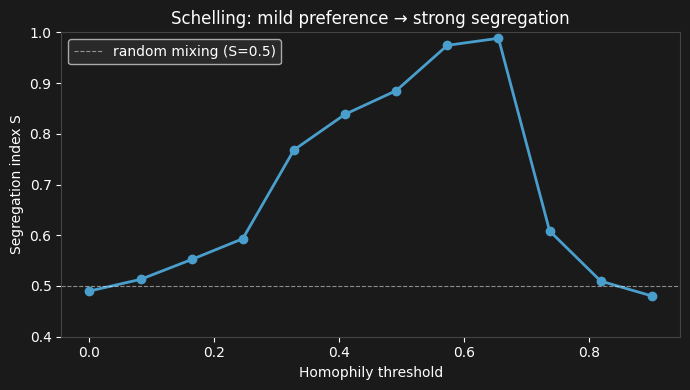


At homophily = 0.4 (agents accept 60% different neighbours):
  Segregation index = 0.838
  (0.5 = random, 1.0 = completely segregated)


In [6]:
# Run a parameter sweep: homophily threshold vs. final segregation index
homophily_values = np.linspace(0.0, 0.9, 12)
segregation_results = []

for h in homophily_values:
    m = Schelling(width=25, height=25, density=0.85, minority_pc=0.5,
                  homophily=h, rng=0)
    for _ in range(60):
        if not m.running:
            break
        m.step()

    # compute segregation index
    fractions = []
    for agent in m.agents:
        neighbors = list(agent.cell.get_neighborhood(radius=1).agents)
        if neighbors:
            same = sum(1 for n in neighbors if n.type == agent.type)
            fractions.append(same / len(neighbors))
    segregation_results.append(np.mean(fractions) if fractions else 0)

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(homophily_values, segregation_results, "o-", color="#4A9ECC", lw=2, ms=6)
ax2.axhline(0.5, color="white", lw=0.8, ls="--", alpha=0.5, label="random mixing (S=0.5)")
ax2.set_xlabel("Homophily threshold", color="white")
ax2.set_ylabel("Segregation index S", color="white")
ax2.set_title("Schelling: mild preference → strong segregation", color="white")
ax2.set_facecolor("#1A1A1A")
fig2.patch.set_facecolor("#1A1A1A")
ax2.tick_params(colors="white")
ax2.spines[:].set_color("#444444")
ax2.legend(facecolor="#2D2D2D", labelcolor="white")
ax2.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

print(f"\nAt homophily = 0.4 (agents accept 60% different neighbours):")
idx = np.argmin(np.abs(homophily_values - 0.4))
print(f"  Segregation index = {segregation_results[idx]:.3f}")
print(f"  (0.5 = random, 1.0 = completely segregated)")